# Compare MEG and iEEG component spaces

This notebook displays results from `compare_subspace.py`; run the expensive analysis on the cluster first.

**Primary scope:** new trials from the same participants and locations. Trial partitions are train/tune/test A/test B. Dimensions are a prespecified sensitivity grid, not selected on test similarity. Repetitions refit the entire model and vary trial splits and MEG pairing; their range is descriptive, not a confidence interval.

Temporal representations : condition × time rows. \
Spatial representations : forward patterns evaluated on the common electrode grid. 


In [3]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if not (ROOT / 'compare_subspace.py').exists() and (ROOT / 'iEEGvsMEG' / 'compare_subspace.py').exists():
    ROOT = ROOT / 'iEEGvsMEG'
sys.path.insert(0, str(ROOT))
from compare_subspace import load_results, plot_results

MEG_KIND = 'paired_coverage'  # full_average, full_concatenated, coverage_average, paired_coverage, random_control
OUTPUT_DIR = ROOT / 'out' / 'compare_subspace' / MEG_KIND
DISPLAY_K = 3 

## Run the analysis

Run on the cluster: \
 python -u compare_subspace.py --root /path/to/iEEGvsMEG 
    --meg-kind paired_coverage --models separate_pca plssvd joint_pca
    --dimensions 1 2 3 5 10 --repeats 5 --block-scaling equal_variance



In [4]:
config, tables = load_results(OUTPUT_DIR)
display(pd.Series(config, name='Run configuration'))
plot_results(OUTPUT_DIR, k=DISPLAY_K, show=False)

cache_dir                 /users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/...
meg_kind                                                    paired_coverage
models                                    [separate_pca, plssvd, joint_pca]
dimensions                                                 [1, 2, 3, 5, 10]
repeats                                                                   5
seed                                                                   2026
block_scaling                                                equal_variance
split_unit                                                            trial
cluster_counts                                              [2, 3, 4, 5, 6]
ridge_grid                                       [0.0001, 0.01, 1.0, 100.0]
max_gram_gib                                                            2.0
scope                             new trials at fixed participant locations
spatial_representation               forward patterns on the electrode grid
normalizatio

['/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/compare_subspace/paired_coverage/subspace_overlap.png',
 '/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/compare_subspace/paired_coverage/alignment_complexity_k3.png',
 '/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/compare_subspace/paired_coverage/within_modality_reliability.png',
 '/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/compare_subspace/paired_coverage/cluster_stability_agreement.png']

## 1. Subspace overlap versus dimension

Mean squared cosine of principal angles between centered column spaces: 1 means identical subspaces at full requested rank; 0 means orthogonal. Rank loss is reported and missing dimensions count as zero. Compare methods at the same dimension; larger dimensions can increase overlap mechanically.

Temporal scores and spatial patterns answer distinct questions. High overlap alone does not demonstrate condition-specific biology. Plot lines show medians, and shading shows the range across overlapping repetitions.


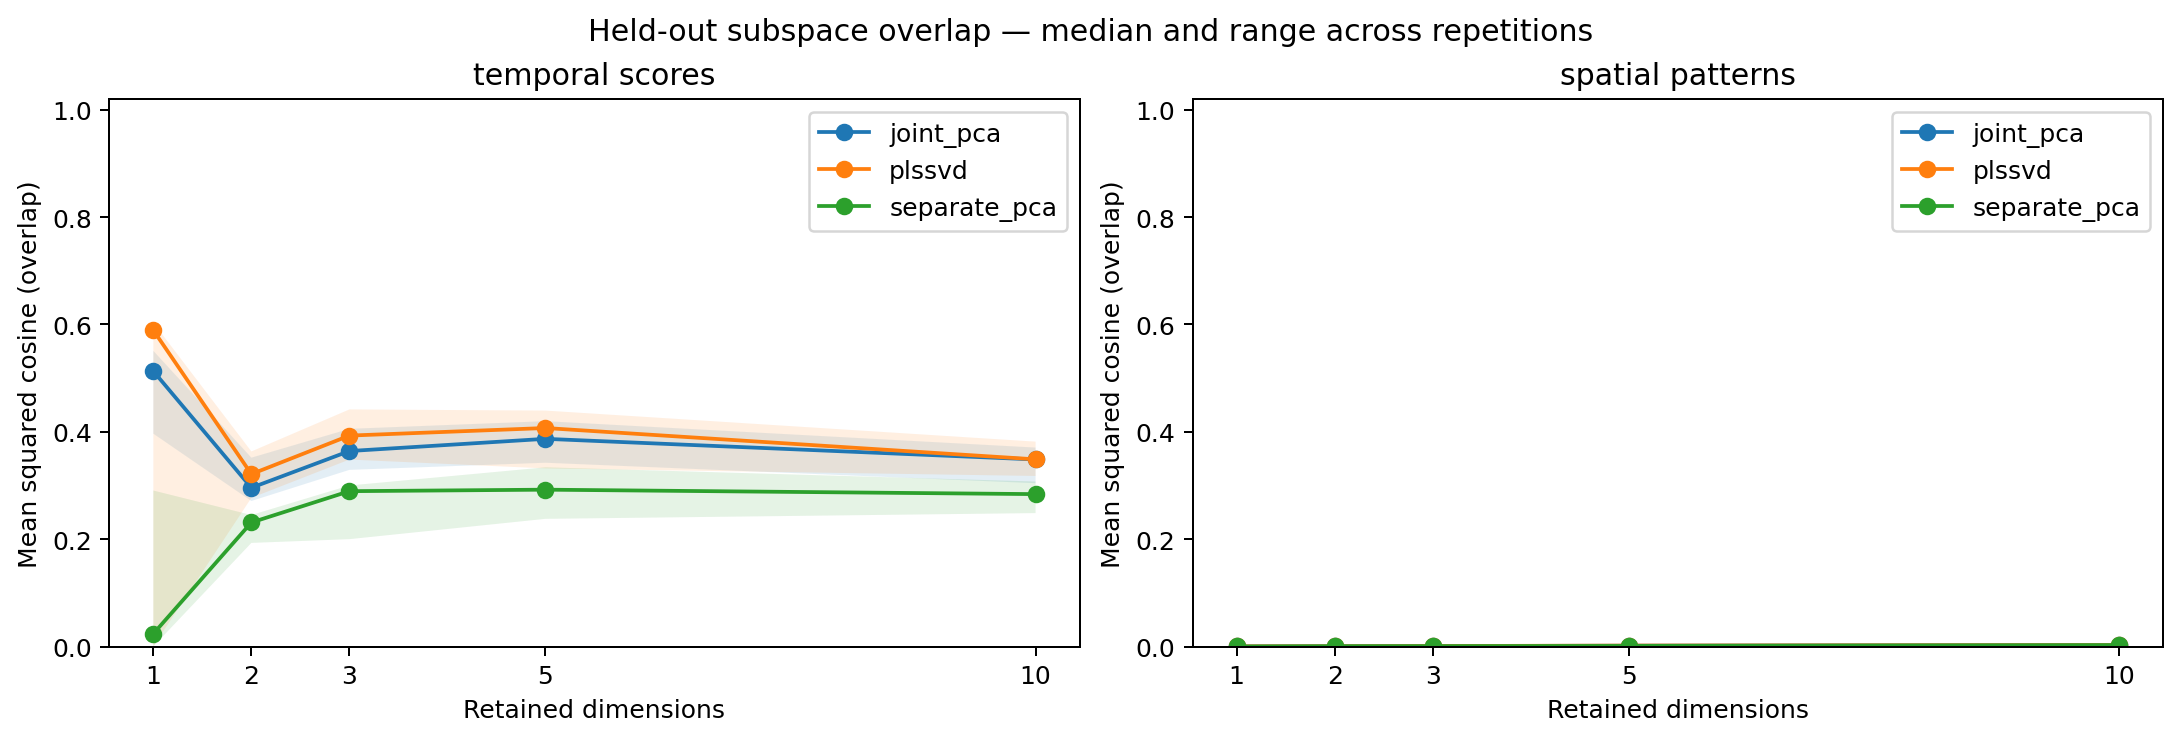

,model,repeat,space,k,overlap,rank_a,rank_b,angles_deg
4,separate_pca,0,temporal_scores,1,2.905731e-01,1,1,[57.38112094823728]
9,separate_pca,0,spatial_patterns,1,1.780596e-08,1,1,[89.99235451004782]
14,separate_pca,0,temporal_scores,2,2.315130e-01,2,2,"[47.15906435035589, 88.5134088299144]"
19,separate_pca,0,spatial_patterns,2,1.590725e-04,2,2,"[88.97798576938469, 89.99747148497462]"
24,separate_pca,0,temporal_scores,3,2.875515e-01,3,3,"[44.14534243127614, 54.85059047117213, 82.6655..."
...,...,...,...,...,...,...,...,...
729,joint_pca,4,spatial_patterns,3,9.030890e-04,3,3,"[87.67644519380411, 88.25731470334902, 89.3202..."
734,joint_pca,4,temporal_scores,5,3.423698e-01,5,5,"[31.731688517583468, 41.25857331899167, 58.743..."
739,joint_pca,4,spatial_patterns,5,1.723943e-03,5,5,"[85.89357267757713, 87.2126908516937, 88.62155..."
744,joint_pca,4,temporal_scores,10,3.140623e-01,10,10,"[28.687084661586013, 34.640716555897576, 43.39..."


In [5]:
display(Image(filename=str(OUTPUT_DIR / 'subspace_overlap.png')))
display(tables['overlap'].query("partition == 'test'")[
    ['model', 'repeat', 'space', 'k', 'overlap', 'rank_a', 'rank_b', 'angles_deg']])


## 2. Held-out alignment error by transformation complexity

Each modality is centered and divided by one scalar RMS estimated on training representations, preserving its relative axis geometry. Compare identity, orthogonal rotation/reflection, regularized affine, and regularized quadratic mappings in both directions. Ridge penalties are selected using **tuning** error independently for each model, dimension, direction and representation.

Normalized error = `||prediction − target|| / ||target − training target mean||`. Values below 1 beat the training-mean baseline; `Q² = 1 − error²`. Mappings are frozen before evaluating independent test trial averages. Spatial locations and time rows recur across partitions; this is not held-out-location or held-out-time generalization. Flexible transformations should earn their complexity through reproducible test improvements.


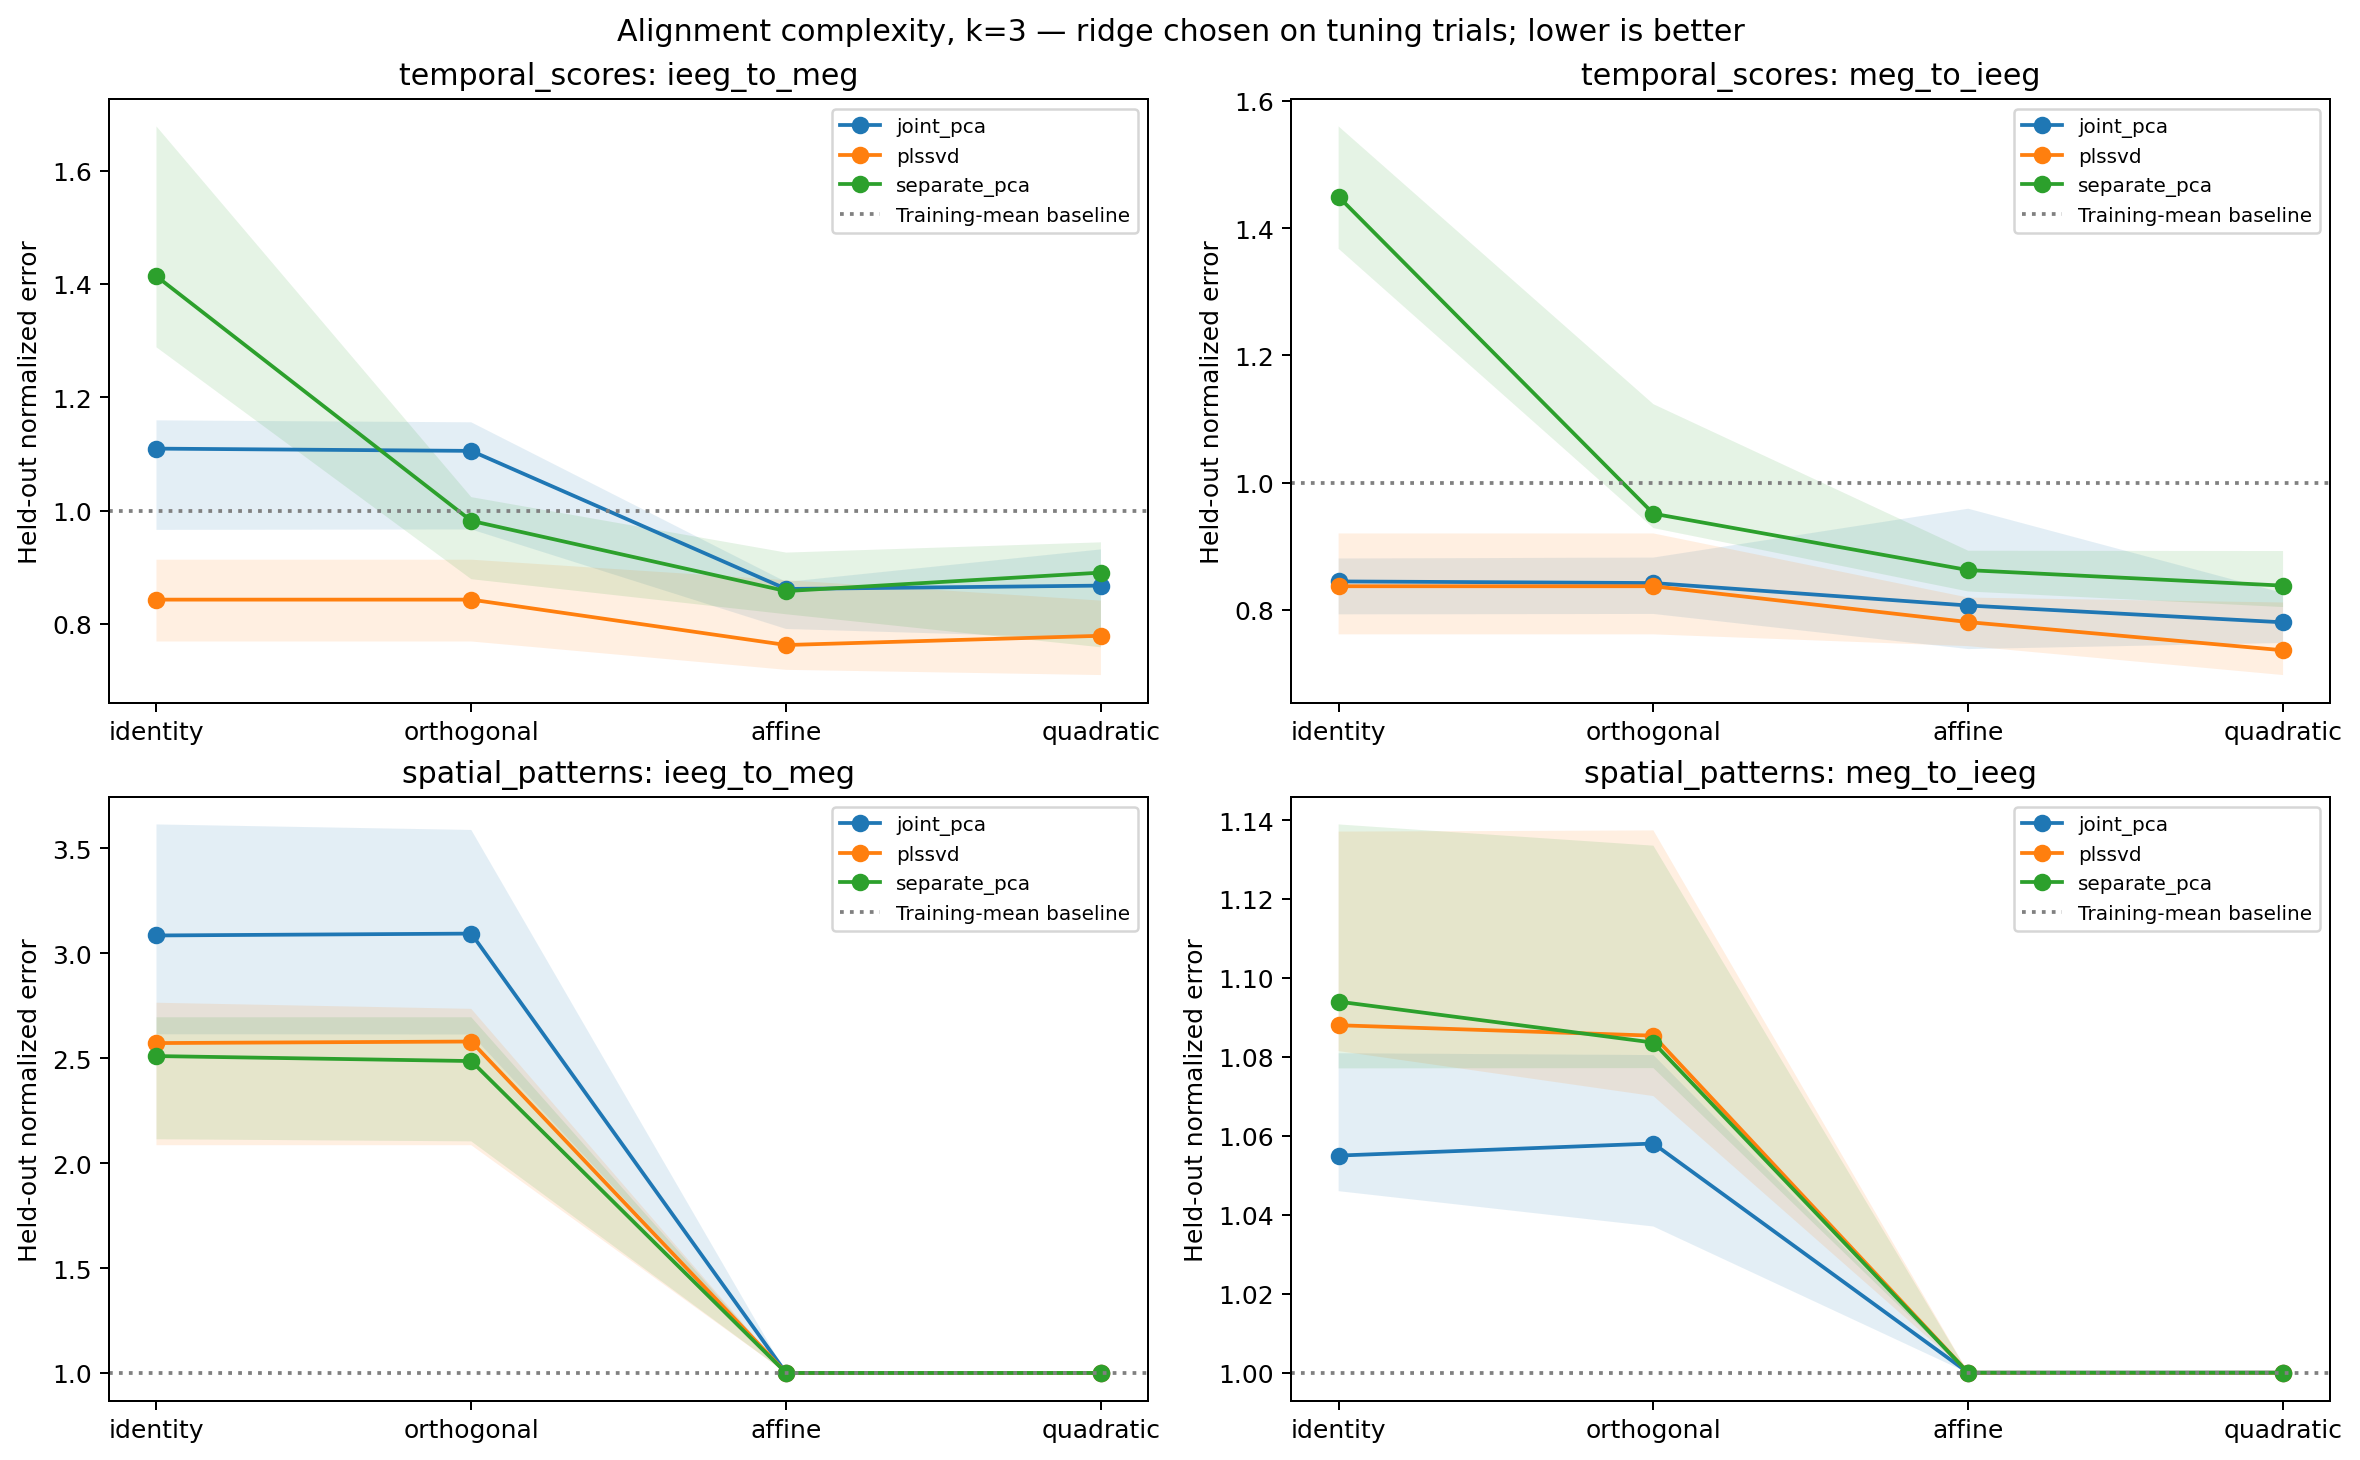

,model,repeat,space,direction,complexity,alpha,nrmse,q2
164,separate_pca,0,temporal_scores,ieeg_to_meg,identity,0.0000,1.677805,-1.815029
169,separate_pca,0,temporal_scores,ieeg_to_meg,orthogonal,0.0000,0.998799,0.002401
174,separate_pca,0,temporal_scores,ieeg_to_meg,affine,0.0100,0.925822,0.142853
179,separate_pca,0,temporal_scores,ieeg_to_meg,quadratic,1.0000,0.890518,0.206977
184,separate_pca,0,temporal_scores,meg_to_ieeg,identity,0.0000,1.559833,-1.433078
...,...,...,...,...,...,...,...,...
5819,joint_pca,4,spatial_patterns,ieeg_to_meg,quadratic,100.0000,0.999721,0.000558
5824,joint_pca,4,spatial_patterns,meg_to_ieeg,identity,0.0000,1.055011,-0.113049
5829,joint_pca,4,spatial_patterns,meg_to_ieeg,orthogonal,0.0000,1.058066,-0.119504
5834,joint_pca,4,spatial_patterns,meg_to_ieeg,affine,0.0001,1.000102,-0.000205


In [6]:
display(Image(filename=str(OUTPUT_DIR / f'alignment_complexity_k{DISPLAY_K}.png')))
display(tables['alignment'].query("partition == 'test' and k == @DISPLAY_K")[
    ['model', 'repeat', 'space', 'direction', 'complexity', 'alpha', 'nrmse', 'q2']])


## 3. Within-modality reliability

Compare test A and test B using the same trained projection axes. This measures reliability of new-trial scores and forward patterns conditional on the model; repetitions additionally refit the model, but the bands are not independent-refit reliability estimates or confidence intervals. The table includes signed correlations of corresponding fixed components.

Use within-modality reproducibility as context for cross-modal overlap, not as a calibrated numerical ceiling. Trials are split within each modality and participant; no trial-by-trial pairing across MEG and iEEG is assumed.


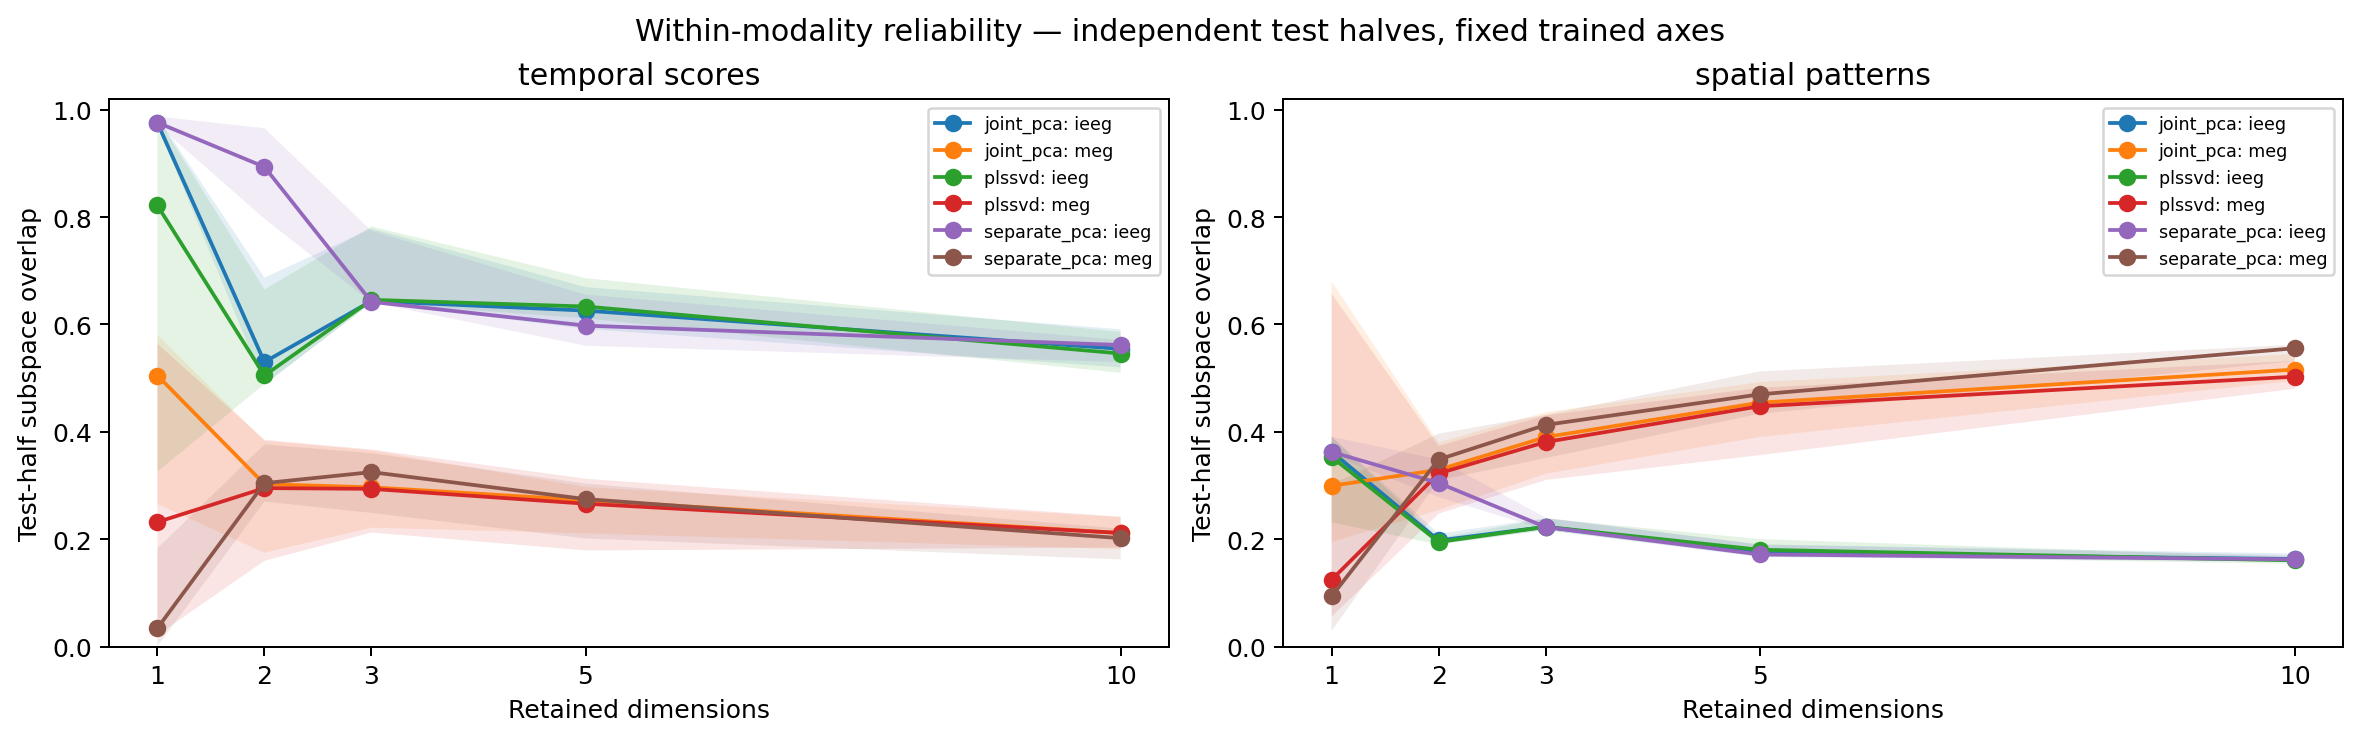

,model,repeat,space,modality,overlap,mean_signed_r,component_r
8,separate_pca,0,temporal_scores,ieeg,0.774456,0.890555,"[0.9882307057635595, 0.781465562788634, 0.9019..."
9,separate_pca,0,temporal_scores,meg,0.260014,0.342478,"[-0.023756644588427016, 0.7089406550495758, 0...."
10,separate_pca,0,spatial_patterns,ieeg,0.222545,0.297567,"[0.5578933161960107, 0.16066026506327674, 0.17..."
11,separate_pca,0,spatial_patterns,meg,0.351107,0.527943,"[0.3335055402096776, 0.737427025953668, 0.5128..."
28,plssvd,0,temporal_scores,ieeg,0.782520,0.942096,"[0.9012440777860413, 0.966264650021198, 0.9587..."
29,plssvd,0,temporal_scores,meg,0.212407,0.406249,"[0.29965682694629603, 0.579466186491808, 0.339..."
30,plssvd,0,spatial_patterns,ieeg,0.223014,0.274603,"[0.15471549665587406, 0.18916022918748296, 0.4..."
31,plssvd,0,spatial_patterns,meg,0.310140,0.466027,"[0.3357726050370365, 0.5781952094636216, 0.484..."
48,joint_pca,0,temporal_scores,ieeg,0.778561,0.812171,"[0.9858144492629984, 0.49599168725589443, 0.95..."
49,joint_pca,0,temporal_scores,meg,0.221410,0.281094,"[0.541300788264659, -0.08258197725505645, 0.38..."


In [7]:
display(Image(filename=str(OUTPUT_DIR / 'within_modality_reliability.png')))
display(tables['reliability'].query('k == @DISPLAY_K')[
    ['model', 'repeat', 'space', 'modality', 'overlap', 'mean_signed_r', 'component_r']])


## 4. Cluster stability and agreement

K-means uses all retained dimensions of spatial patterns, separately for each modality. A common cluster count is selected by mean tuning silhouette, never by test agreement. Because orthogonal transformations preserve Euclidean distances, rotating before independent K-means adds no information; Procrustes and clustering are evaluated separately.

- **Cross-modal ARI:** agreement on the same ordered electrode locations using held-out patterns assigned to training centroids.
- **Fixed-centroid stability:** test A versus test B assignments to frozen training centroids, within a modality.
- **Refit stability:** independently cluster test A and test B using the training/tuning-selected cluster count, then compare partitions. Projection axes remain fixed.

ARI is invariant to cluster label numbering; 1 indicates identical partitions and 0 is chance-adjusted agreement. Silhouette is a compactness diagnostic, not evidence that discrete biological clusters exist. These cluster metrics are descriptive and do not treat correlated electrodes as independent inferential samples.


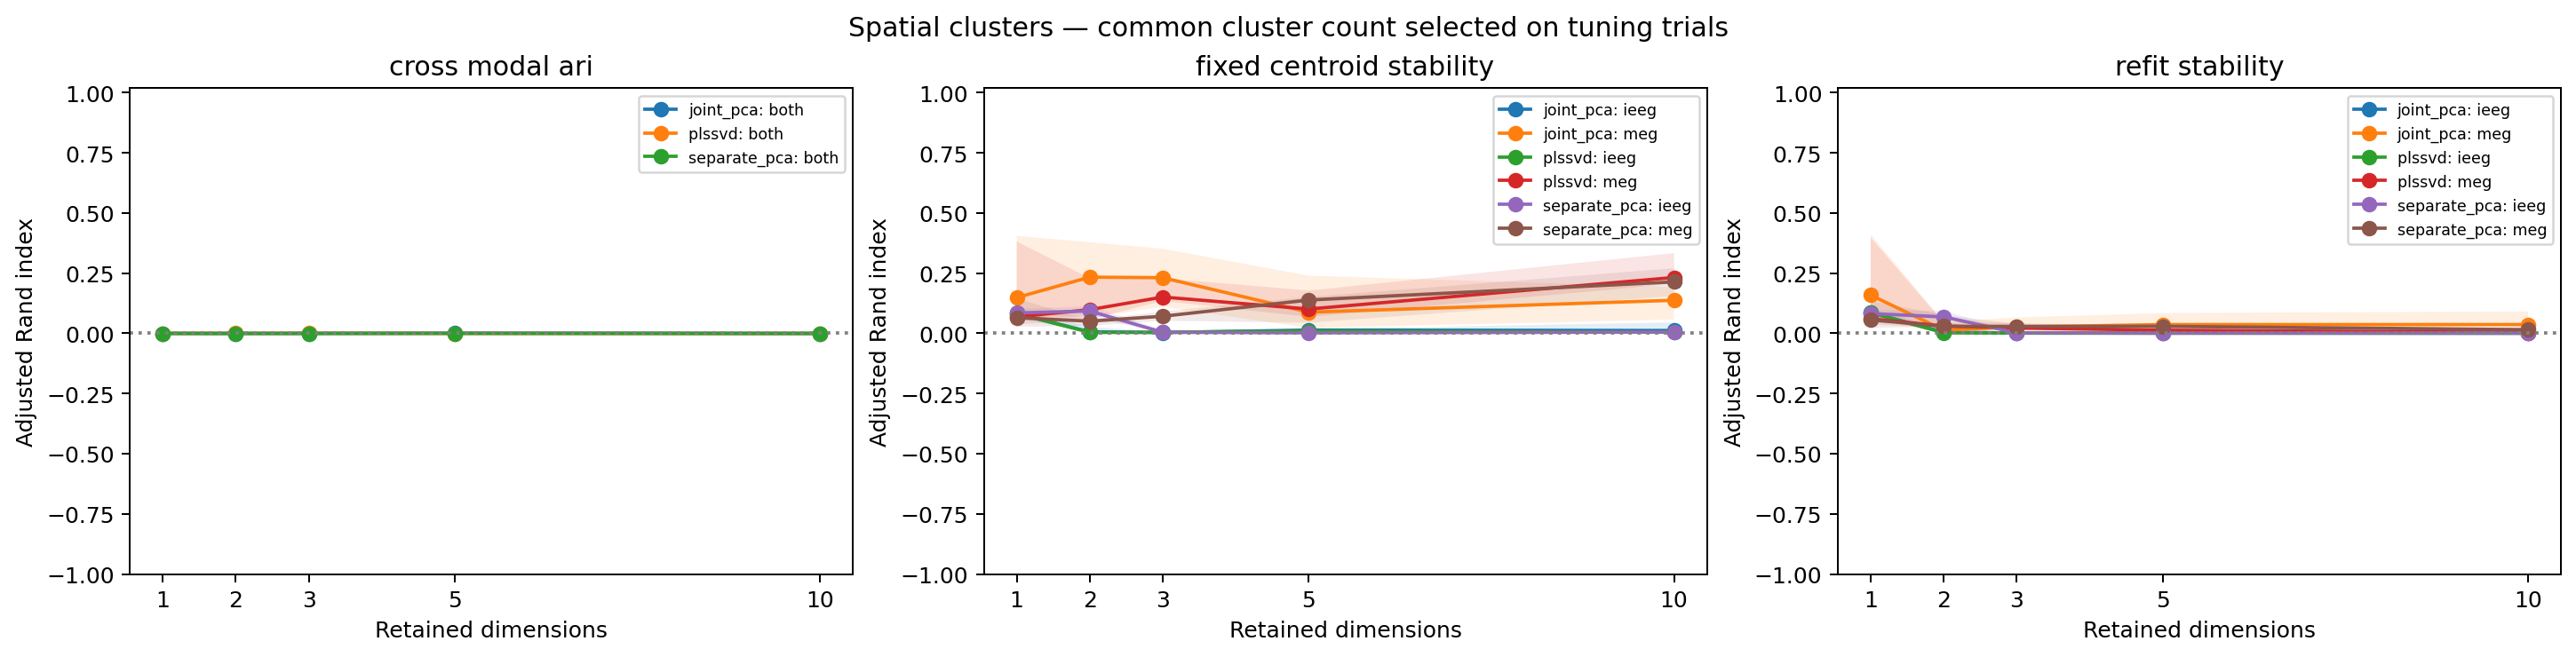

,model,repeat,k,metric,modality,partition,value,n_clusters
18,separate_pca,0,3,cross_modal_ari,both,test_a,0.000233,2
19,separate_pca,0,3,cross_modal_ari,both,test_b,-0.000388,2
20,separate_pca,0,3,cross_modal_ari,both,test,0.000627,2
21,separate_pca,0,3,fixed_centroid_stability,ieeg,test_a_vs_test_b,0.013728,2
22,separate_pca,0,3,refit_stability,ieeg,test_a_vs_test_b,0.000123,2
...,...,...,...,...,...,...,...,...
652,joint_pca,4,3,refit_stability,ieeg,test_a_vs_test_b,0.001060,2
653,joint_pca,4,3,test_silhouette,ieeg,test,0.489820,2
654,joint_pca,4,3,fixed_centroid_stability,meg,test_a_vs_test_b,0.231301,2
655,joint_pca,4,3,refit_stability,meg,test_a_vs_test_b,0.018291,2


,model,repeat,k,n_clusters,ieeg_silhouette,meg_silhouette,selection_score
10,separate_pca,0,3,2,0.372266,0.387881,0.380074
11,separate_pca,0,3,3,0.198068,0.264988,0.231528
12,separate_pca,0,3,4,0.181835,0.256671,0.219253
13,separate_pca,0,3,5,0.156797,0.186660,0.171728
14,separate_pca,0,3,6,0.125580,0.149169,0.137374
...,...,...,...,...,...,...,...
360,joint_pca,4,3,2,0.480449,0.226861,0.353655
361,joint_pca,4,3,3,0.110915,0.237565,0.174240
362,joint_pca,4,3,4,0.084827,0.206232,0.145530
363,joint_pca,4,3,5,0.088051,0.229229,0.158640


In [8]:
display(Image(filename=str(OUTPUT_DIR / 'cluster_stability_agreement.png')))
display(tables['clusters'].query('k == @DISPLAY_K'))
display(tables['cluster_selection'].query('k == @DISPLAY_K'))
